In [1]:
import numpy as np
from pycvxset import Polytope
from adaptive_tools import SetUpdater
from invariance_tools import GainSynthesis
from cartesian_product import cartesian_product
from cRMPC import CRMPC

In [ ]:
A = np.array(
            [
                [
                    [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 6.55847073e-03,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00]],
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 9.62477033e-01, -2.70418272e-01, -3.54535263e-01, -1.08121033e-01],
                    [ 6.03978994e-02, -3.51946037e-01, -6.16284799e-01, 1.82183285e-01],
                    [-2.98716243e-03, -3.30481599e-02, -3.49541770e-05, 1.52896134e-02]],
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [-4.21460547e-02,  1.48734527e-01,  2.49708275e-01, 1.46475140e-01],
                    [ 9.32949059e-01,  2.33489450e-01,  3.84304411e-01, -1.35325598e-02],
                    [-9.96893529e-03,  1.42242452e-02,  5.02034057e-03, -4.66406071e-02]],
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [-2.59938961e-02, -2.63172399e-02,  4.65109389e-03, 3.00565144e-01],
                    [-1.59201270e-03, -2.02848177e-02, -2.60380154e-02, 3.90983528e-01],
                    [ 8.70485640e-01, -5.48457771e-02,  3.24459921e-02, 6.67191728e-02]]])
B = np.array(
            [
                [
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00],
                    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 0.00000000e+00]],
                [
                    [ 8.40916986e-02, -6.74379191e-01,  4.14184808e-01, 6.96994653e-02],
                    [ 1.37701713e-02,  2.87919480e-02, -9.12432271e-02, -2.99699931e-01]],
                [
                    [-1.02160995e-02,  5.14789438e-01, -3.00694970e-01, 2.04723249e-01],
                    [ 2.58556998e-04, -4.44445006e-03,  4.10364069e-02, 3.52610402e-01]],
                [
                    [ 2.28217366e-02, -1.76918468e-02,  8.71910634e-02, 6.08327604e-01],
                    [ 1.31207096e-01,  2.19817108e-03,  5.56598339e-02, -2.28968692e-01]]])

C = np.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
C = np.stack([C, np.zeros((2, 4)), np.zeros((2, 4)), np.zeros((2, 4))], axis=2)

A_B=np.concatenate( (A, B), axis=1).transpose(2, 0, 1)

E = Polytope(
                A=np.vstack((np.eye(2), -np.eye(2))),
                b=np.concatenate((np.ones(2) * 0.01, np.ones(2) * 0.01)),
            )
W = Polytope(
                A=np.block([[np.eye(4)], [-np.eye(4)]]), b=0.05 * np.ones((8, 1))
            )
Theta_c = Polytope(V=np.eye(0))

In [ ]:
B.shape, A.shape, C.shape

In [ ]:
max_p, min_p = ([np.float64(-0.23350), np.float64(1.37460), np.float64(0.31949)], [np.float64(-1.81833),np.float64(-0.26129),np.float64(-0.61740)])

Theta = Polytope(A=np.block([[np.eye(3)], [-np.eye(3)]]), b=np.block([np.array(max_p), -np.array(min_p)]))  # np.block([np.array(max_p), -np.array(min_p)])
Theta.plot()
Theta.V

SetUpdater(A_B, C.transpose(2, 0, 1), Theta, Theta_c, W, E, 1)

In [ ]:
lbx, ubx = (np.array([-1e4,-0.46, -0.01, -1.90]), np.array([1e4, 0.46, 0.01, 1.90]))
x = Polytope(A=np.block([[np.eye(4)], [-np.eye(4)]]), b=np.concatenate(([1e4, 0.46, 0.01, 1.90], np.array([1e4, 0.46, 0.01, 1.90]))))
u = Polytope(A=np.block([[np.eye(2)], [-np.eye(2)]]), b=np.concatenate(([0.46, 1.90], np.array([0.46, 1.90]))))
z = cartesian_product(x, u)
Q = np.eye(4)
R = np.diag([1/(0.46**2), 1/(1.90**2)])  # np.diag([1/(0.46**2), 1/(1.90**2), 1, 1])
gain_synth = GainSynthesis(
            A, B,
            Q=Q, R=R,
            Z_bnd=z, W=W,
            mode='LQR', contraction_factor=1)
gain_synth.synthesize_controller()

## Test totale

In [4]:
npzfile = np.load('system_matrices.npz')
A, B = npzfile['arr_0'], npzfile['arr_1']
A_B=np.concatenate( (A, B), axis=1).transpose(2, 0, 1)
C = np.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
C = np.stack([C, np.zeros((2, 4)), np.zeros((2, 4)), np.zeros((2, 4))], axis=2)
W = Polytope(
                A=np.block([[np.eye(4)], [-np.eye(4)]]), b=0.001 * np.ones((8, 1))
            )

E = Polytope(
                A=np.vstack((np.eye(2), -np.eye(2))),
                b=np.concatenate((np.ones(2) * 0.01, np.ones(2) * 0.01)),
            )

Theta_c = Polytope()

max_p, min_p = ([np.float64(-0.23350), np.float64(1.37460), np.float64(0.31949)], [np.float64(-1.81833),np.float64(-0.26129),np.float64(-0.61740)])

Theta = Polytope(A=np.block([[np.eye(3)], [-np.eye(3)]]), b=np.block([np.array(max_p), -np.array(min_p)]))  # np.block([np.array(max_p), -np.array(min_p)])

Q, R = np.eye(4), np.eye(2) #np.diag([1/(0.46**2), 1/(1.90**2)])
K = np.array(
    [
        [-7.57855882e-03, -6.40593493e-01, -1.83721441e-01, 5.62371887e-01],
        [-5.07279439e-05,  8.12719728e-02,  7.37019877e-02, 6.28097473e-02
         ]
        ]
    )

opt = {
    'K': K,
    "solver": 'osqp',
    "verbose": False,
    "svd": False,
    "xBound": (np.array([-1e4,-0.46, -0.01, -1.90]), np.array([1e4, 0.46, 0.01, 1.90])),
    "uBound": (np.array([-0.46, -1.90]), np.array([0.46, 1.90])),
    "name": 'tet_mpc',
    "W": W,
    'E': E,
    "theta": Theta,
    "lam": 0.98,
    'par_filter': 'lms',
    # 'ref': 'trajectory',
}

In [5]:
controller = CRMPC({'A': A, 'B': B, 'C': C},
                         Q, R, 10, opt)
controller.initialize("LQR")
controller.P = np.array(
    [
        [ 1.90584932e+04, -3.11708260e+04, -2.18046990e+04, -3.82077431e+05],
        [-3.11708260e+04,  1.35038780e+07,  1.21994189e+07, -1.29229345e+07],
        [-2.18046990e+04,  1.21994189e+07,  1.24390961e+07, -1.31640429e+07],
        [-3.82077431e+05, -1.29229345e+07, -1.31640429e+07, 5.73129788e+07]
    ]
)

Convergence reached after 11 iterations


/home/stream/Personals/Fabio/ros2_ws/src/cRAMPC/cRAMPC/cRMPC.py:875: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  w_lp.solve()


map10_lin_constr(horzcat(x[:40]', u')', repmat([-0, -0, -100, -0, -0, -0], 10)){0}'
map10_lin_constr(horzcat(x[:40]', u')', repmat([-0, -2.17391, -0, -0, -0, -0], 10)){0}'
map10_lin_constr(horzcat(x[:40]', u')', repmat([5.55112e-21, 1.20676e-16, 5.55112e-15, 2.92164e-17, 1.20676e-16, -0.526316], 10)){0}'
map10_lin_constr(horzcat(x[:40]', u')', repmat([-0, -0, 100, -0, -0, -0], 10)){0}'
map10_lin_constr(horzcat(x[:40]', u')', repmat([5.55112e-21, 1.20676e-16, 5.55112e-15, -0.526316, -0, -0], 10)){0}'
map10_lin_constr(horzcat(x[:40]', u')', repmat([-0, -0, -0, -0, -2.17391, -0], 10)){0}'
0x1
(x[:4]-x_init)
step(zeros(4x1), zeros(2x1), (reshape(mac(
[[0, 0, 0, 0], 
 [0, 0, 0, 0], 
 [0, 0, 0, 0], 
 [29.5874, 0, 0, 0], 
 [0, 0, 0, 0], 
 [0.962477, -0.270938, -0.351028, -0.0588272], 
 [0.04045, -0.236328, -0.412851, 0.089071], 
 [-0.0277773, -0.379883, 0.0341562, 1.00136], 
 [0, 0, 0, 0], 
 [-0.0629304, 0.222582, 0.365803, 0.135438], 
 [0.932949, 0.233645, 0.383476, -0.0156192], 
 [-0.138415

In [7]:
controller.solve([0.3, 0.5, 0.01, 0.1])
controller.u_star

iter   objective    pri res    dua res    rho
   1   0.0000e+00   5.00e-01   1.15e-01   1.00e-06
 200   7.0821e-01   8.96e+01   1.33e-02   1.30e-05
 400   2.0810e+00   1.13e+02   3.81e-02   1.30e-05
 600   3.6562e+00   9.19e+01   2.18e-02   1.30e-05
 800   5.1397e+00   7.66e+01   3.43e-02   1.30e-05
1000   6.3914e+00   1.13e+02   9.33e-03   1.30e-05
1200   7.3912e+00   8.93e+01   1.56e-02   1.30e-05
1400   8.1923e+00   8.78e+01   1.56e-02   1.30e-05
1600   8.8311e+00   1.02e+02   3.16e-02   1.30e-05
1800   9.2805e+00   1.20e+02   1.65e-02   1.30e-05
2000   9.6279e+00   9.31e+01   1.48e-02   1.30e-05
2200   9.9256e+00   8.12e+01   4.73e-02   1.30e-05
2400   1.0113e+01   1.36e+02   5.36e-02   1.30e-05
2600   1.0256e+01   9.12e+01   3.09e-02   1.30e-05
2800   1.0400e+01   8.83e+01   5.06e-02   1.30e-05
3000   1.0500e+01   1.31e+02   6.66e-02   1.30e-05
3200   1.0561e+01   9.58e+01   3.15e-02   1.30e-05
3400   1.0638e+01   1.06e+02   5.36e-02   1.30e-05
3600   1.0681e+01   1.23e+02   4.93e

DM([-0.39486, -0.628893])

## Create a circle trajectory

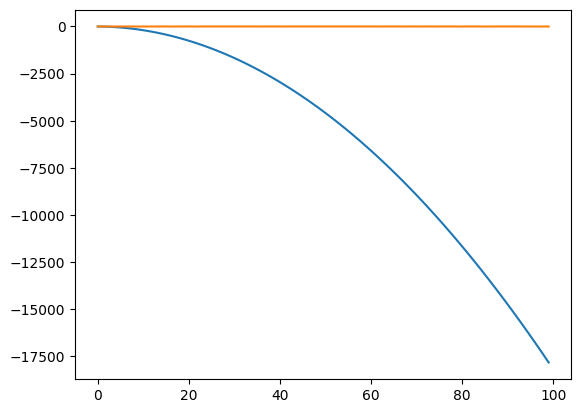

In [5]:
import numpy as np
from matplotlib import pyplot as plt

delta_theta = [0]
speed_x = [0]

for i in range(1, 100):
    delta_theta.append(delta_theta[-1] - 2*np.pi*i/100)
    speed_x.append(np.cos(delta_theta[-1]))

# Export to csv file
import pandas as pd
df = pd.DataFrame({'delta_theta': delta_theta, 'speed_x': speed_x})
df.to_csv('trajectory_circle.csv', index=False)

plt.plot(np.rad2deg(delta_theta))
plt.plot(speed_x)

In [ ]:
import numpy as np
npzread = np.load('/home/stream/Personals/Fabio/ros2_ws/src/cRAMPC/config/system_matrices.npz')
A, B = npzread['arr_0'], npzread['arr_1']
A

array([[-1.44211354e-03, -2.66357680e-01, -2.41992696e-01,
         1.59236973e+00],
       [-7.28546042e-03,  2.96327363e-02,  6.69755597e-02,
        -1.05182142e+00]])